In [1]:
# Import core data analysis libraries
import pandas as pd
import numpy as np
import os

# Define the path to your raw dataset file
# Using relative paths ensures this code runs smoothly on any machine
data_path = os.path.join("..", "data", "raw", "AI_Classification-Project.csv")

# Load the dataset into a Pandas DataFrame
# We wrap this in a try-except block to handle file path errors gracefully
try:
    df = pd.read_csv(data_path)
    print(f"Successfully loaded dataset with {df.shape[0]} rows and {df.shape[1]} columns.")
except FileNotFoundError:
    print(f"Error: Could not find the file at {data_path}. Check your folder structure.")

# Display the first 5 rows to understand the column structure
print("\n--- First 5 Rows ---")
display(df.head())

# Check data types and non-null counts to spot any missing values
print("\n--- Dataset Info ---")
df.info()

# Check the distribution of your target variable (authentic vs. fake faces)
# This helps us identify if the dataset is balanced or imbalanced
if 'label' in df.columns:
    print("\n--- Target Class Distribution ---")
    print(df['label'].value_counts())
else:
    print("\nWarning: 'label' column not found. Check your column names.")

Successfully loaded dataset with 6557 rows and 17 columns.

--- First 5 Rows ---


,image_id,image_url,label,label_numeric,category,gender,age_group,source,fake_method,image_quality,resolution,confidence_score,detection_difficulty,dataset_split,date_collected,version,year
0,1,https://images.unsplash.com/photo-172422561835...,REAL,1,Authentic,Female,18-25,Unsplash,NaN,High,1080x1080,0.96,Easy,train,24-04-2026,v2.0,2026
1,2,https://images.unsplash.com/photo-172422561873...,REAL,1,Authentic,Male,50+,Unsplash,NaN,High,1080x1080,0.97,Easy,train,04-04-2026,v2.0,2026
2,3,https://images.unsplash.com/photo-172422561834...,REAL,1,Authentic,Female,36-50,Unsplash,NaN,High,1080x1080,0.95,Easy,test,07-02-2026,v2.0,2026
3,4,https://images.unsplash.com/photo-172422561855...,REAL,1,Authentic,Female,26-35,Unsplash,NaN,High,1080x1080,0.89,Easy,train,20-02-2026,v2.0,2026
4,5,https://images.unsplash.com/photo-172422561823...,REAL,1,Authentic,Male,36-50,Unsplash,NaN,High,1080x1080,0.86,Easy,train,12-04-2026,v2.0,2026



--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 6557 entries, 0 to 6556
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   image_id              6557 non-null   int64  
 1   image_url             6557 non-null   str    
 2   label                 6557 non-null   str    
 3   label_numeric         6557 non-null   int64  
 4   category              6557 non-null   str    
 5   gender                6557 non-null   str    
 6   age_group             6557 non-null   str    
 7   source                6557 non-null   str    
 8   fake_method           3767 non-null   str    
 9   image_quality         6557 non-null   str    
 10  resolution            6557 non-null   str    
 11  confidence_score      6557 non-null   float64
 12  detection_difficulty  6557 non-null   str    
 13  dataset_split         6557 non-null   str    
 14  date_collected        6557 non-null   str    
 15  version   

In [2]:
# Check for any missing/null values across all columns
# This ensures we know if we need to clean or drop missing rows before training
print("--- Missing Values Check ---")
print(df.isnull().sum())

# Inspect the exact distribution of the target variable ('label')
# This lets us know if our dataset is balanced between REAL and FAKE images
print("\n--- Target Label Breakdown ---")
if 'label' in df.columns:
    print(df['label'].value_counts(normalize=True) * 100)
    print("\nAbsolute Counts:")
    print(df['label'].value_counts())
else:
    print("Column 'label' not found.")

--- Missing Values Check ---
image_id                   0
image_url                  0
label                      0
label_numeric              0
category                   0
gender                     0
age_group                  0
source                     0
fake_method             2790
image_quality              0
resolution                 0
confidence_score           0
detection_difficulty       0
dataset_split              0
date_collected             0
version                    0
year                       0
dtype: int64

--- Target Label Breakdown ---
label
FAKE    57.450053
REAL    42.549947
Name: proportion, dtype: float64

Absolute Counts:
label
FAKE    3767
REAL    2790
Name: count, dtype: int64


C:\Users\asus\AppData\Local\Temp\ipykernel_20636\2195476993.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2', ax=axes[0])
C:\Users\asus\AppData\Local\Temp\ipykernel_20636\2195476993.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=fake_df, y='fake_method', palette='viridis',


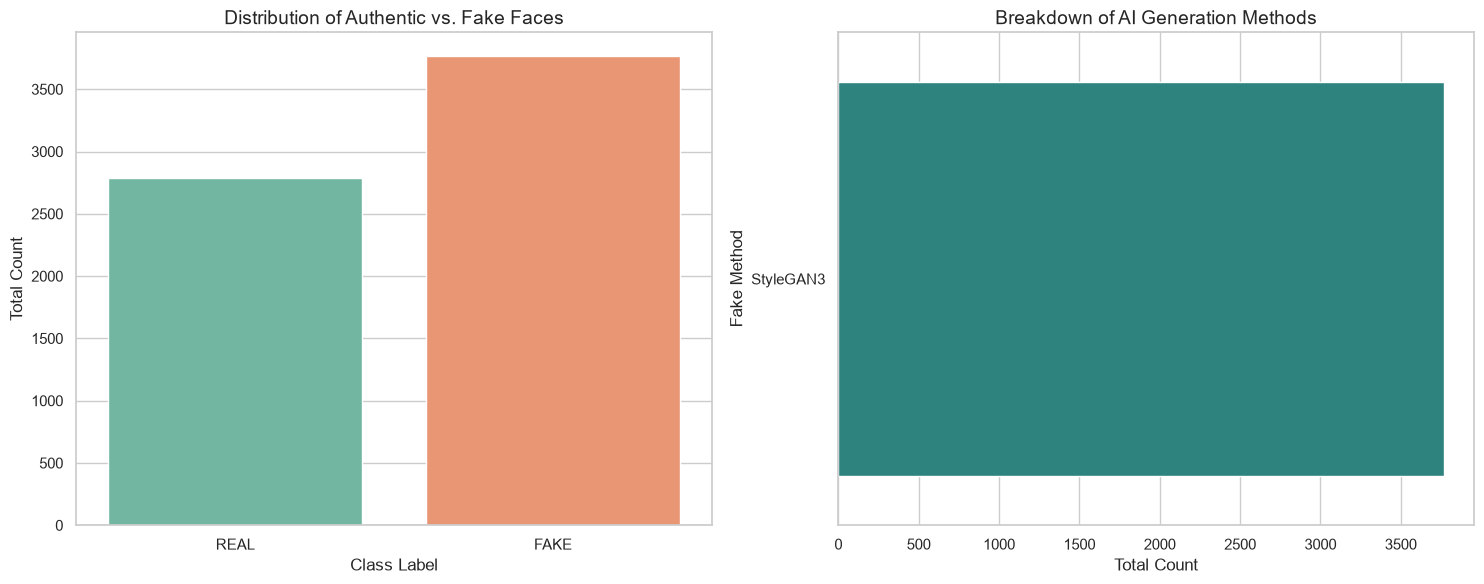

In [3]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic for all plots
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: Overall Target Distribution ---
# This bar chart shows the exact balance of REAL vs. FAKE faces
sns.countplot(data=df, x='label', palette='Set2', ax=axes[0])
axes[0].set_title('Distribution of Authentic vs. Fake Faces', fontsize=14)
axes[0].set_xlabel('Class Label', fontsize=12)
axes[0].set_ylabel('Total Count', fontsize=12)

# --- Plot 2: Fake Methods Breakdown ---
# We filter the dataframe to ONLY show 'FAKE' images, then count the generation methods
fake_df = df[df['label'] == 'FAKE']
sns.countplot(data=fake_df, y='fake_method', palette='viridis', 
              order=fake_df['fake_method'].value_counts().index, ax=axes[1])
axes[1].set_title('Breakdown of AI Generation Methods', fontsize=14)
axes[1].set_xlabel('Total Count', fontsize=12)
axes[1].set_ylabel('Fake Method', fontsize=12)

# Adjust layout to prevent overlap and display the plots
plt.tight_layout()
plt.show()